In [ ]:
from ugot import ugot
got = ugot.UGOT()
got.initialize("192.168.1.185")
got.load_models(["color_recognition", "face_recognition"])

192.168.1.185:50051


True

## Ball/cube Bounding Box

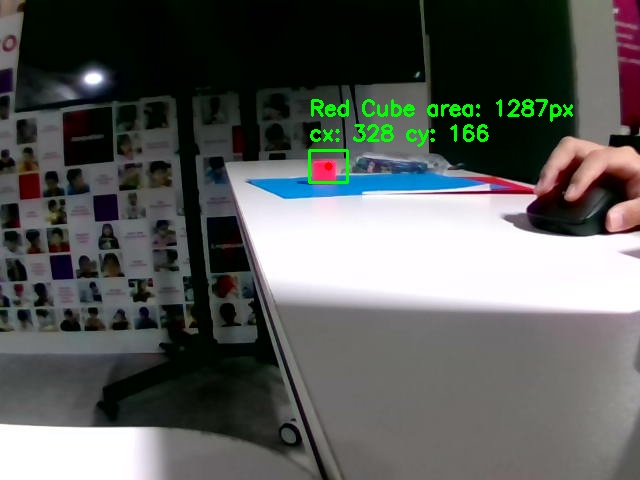

Done


In [4]:
import cv2
import numpy as np
from IPython.display import display, Image, clear_output

got.open_camera()
try:
    while True:
        # Grab the latest camera frame as raw bytes
        frame = got.read_camera_data()

        # Decode the bytes into an OpenCV image array
        nparr = np.frombuffer(frame, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        # Get color recognition result: [color, shape, center_x, center_y, height, width, area]
        result = got.get_color_total_info() 

        if result:
            color, shape, cx, cy, h, w, area = result
            cx, cy = int(cx), int(cy)
            half_w, half_h = int(w / 2), int(h / 2)

            # Compute bounding box corners
            x1, y1 = cx - half_w, cy - half_h
            x2, y2 = cx + half_w, cy + half_h

            # Draw bounding box and center dot
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.circle(img, (cx, cy), 4, (0, 0, 255), -1)

            # Label with color, shape, and area
            lines = [
                f"{color} {shape} area: {area}px",
                f"cx: {cx} cy: {cy}"
            ]

            line_height = 25  # adjust based on font scale
            for i, line in enumerate(lines):
                y = (y1 - 10) - (len(lines) - 1 - i) * line_height
                cv2.putText(img, line, (x1, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        # Encode the annotated frame as JPEG and display it inline in the notebook
        _, jpeg = cv2.imencode(".jpg", img)
        clear_output(wait=True)
        display(Image(data=jpeg.tobytes()))

except KeyboardInterrupt:
    print("Done")
    got.mecanum_stop()

# Deposit check

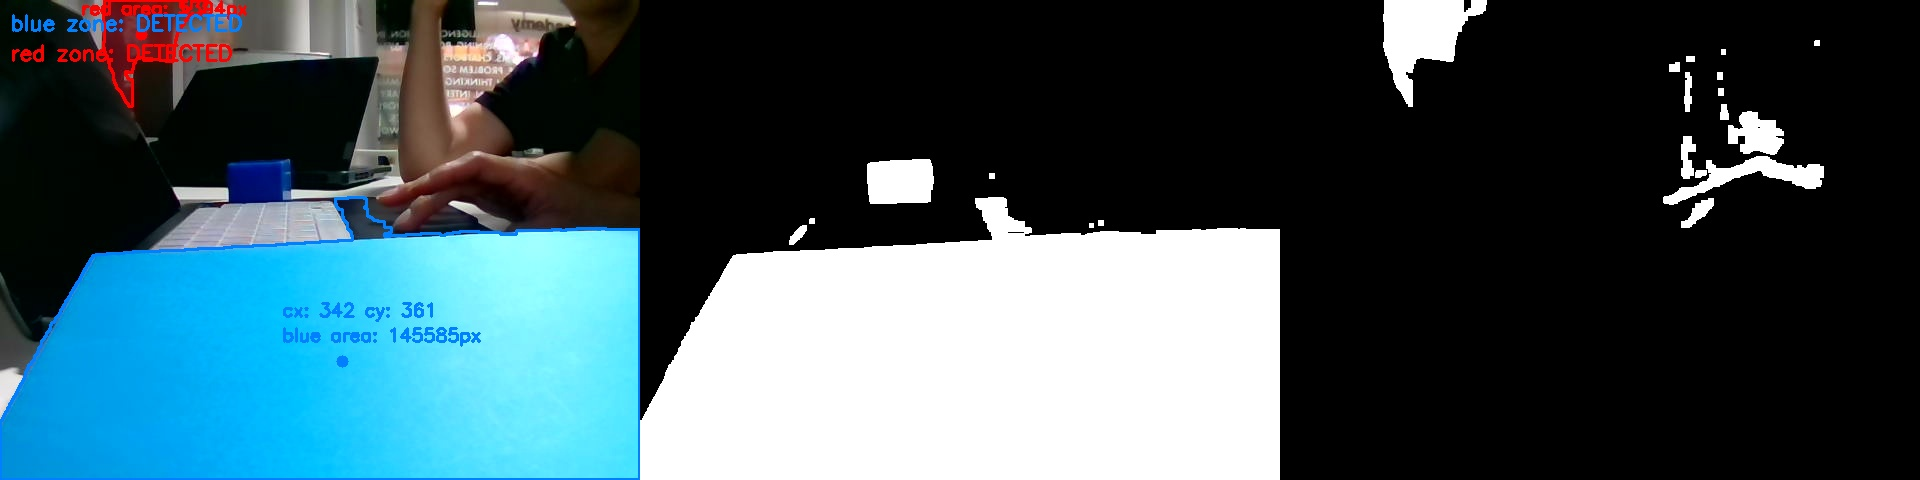

Done


In [9]:
import cv2
import numpy as np
from IPython.display import display, Image, clear_output

# --- Tune these ---
BLUE_HSV_LOWER = np.array([90, 70, 40]) 
BLUE_HSV_UPPER = np.array([135, 255, 255]) 

# Red wraps around 0 in HSV, so it needs two ranges
RED_HSV_LOWER_1 = np.array([0, 70, 70])
RED_HSV_UPPER_1 = np.array([10, 255, 255])
RED_HSV_LOWER_2 = np.array([170, 70, 70])
RED_HSV_UPPER_2 = np.array([180, 255, 255])

MIN_CONTOUR_AREA = 500

got.open_camera()

def detect_zone(img, color):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    if color == "blue":
        mask = cv2.inRange(hsv, BLUE_HSV_LOWER, BLUE_HSV_UPPER)
    elif color == "red":
        mask1 = cv2.inRange(hsv, RED_HSV_LOWER_1, RED_HSV_UPPER_1)
        mask2 = cv2.inRange(hsv, RED_HSV_LOWER_2, RED_HSV_UPPER_2)
        mask = cv2.bitwise_or(mask1, mask2)
    mask = cv2.erode(mask, None, iterations=2)
    mask = cv2.dilate(mask, None, iterations=2)
    return mask

try:
    while True:
        frame = got.read_camera_data()
        nparr = np.frombuffer(frame, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        results = {}
        masks = {}

        for color, draw_color in [("blue", (255, 128, 0)), ("red", (0, 0, 255))]:
            mask = detect_zone(img, color)
            masks[color] = mask
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            results[color] = None
            if contours:
                largest = max(contours, key=cv2.contourArea)
                area = cv2.contourArea(largest)
                if area > MIN_CONTOUR_AREA:
                    M = cv2.moments(largest)
                    if M["m00"] != 0:
                        dcx = int(M["m10"] / M["m00"])
                        dcy = int(M["m01"] / M["m00"])
                        results[color] = (dcx, dcy, int(area))
                        cv2.drawContours(img, [largest], -1, draw_color, 2)
                        cv2.circle(img, (dcx, dcy), 6, draw_color, -1)
                        cv2.putText(img, f"{color} area: {int(area)}px", (dcx - 60, dcy - 20),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, draw_color, 2)
                        cv2.putText(img, f"cx: {dcx} cy: {dcy}", (dcx - 60, dcy - 45),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, draw_color, 2)

        # Status lines for each color
        for i, (color, draw_color) in enumerate([("blue", (255, 128, 0)), ("red", (0, 0, 255))]):
            detected = results[color] is not None
            status = "DETECTED" if detected else "NOT FOUND"
            cv2.putText(img, f"{color} zone: {status}", (10, 30 + i * 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, draw_color, 2)

        # Stack: camera | blue mask | red mask
        blue_bgr = cv2.cvtColor(masks["blue"], cv2.COLOR_GRAY2BGR)
        red_bgr = cv2.cvtColor(masks["red"], cv2.COLOR_GRAY2BGR)
        combined = np.hstack([img, blue_bgr, red_bgr])

        _, jpeg = cv2.imencode(".jpg", combined)
        clear_output(wait=True)
        display(Image(data=jpeg.tobytes()))

except KeyboardInterrupt:
    print("Done")

# Approach cube

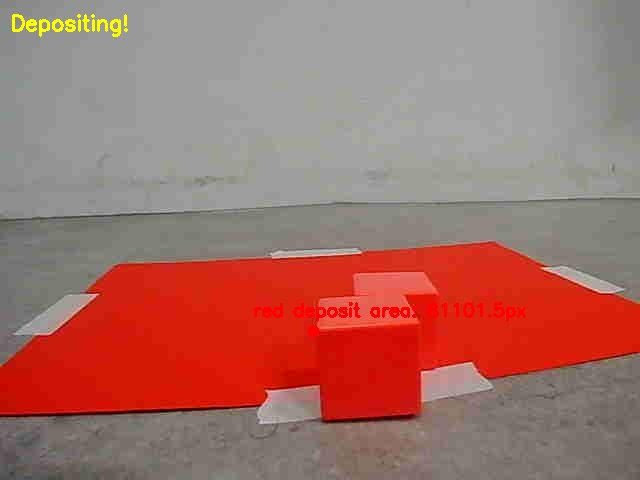

In [ ]:
import cv2
import numpy as np
from IPython.display import display, Image, clear_output

# --- Tuning constants ---
FRAME_W, FRAME_H = 640, 480
CENTER_TOLERANCE = 20
CLOSE_AREA_THRESHOLD = {
    "Red": 18000,
    "Blue": 18000,
}
DEPOSIT_AREA_THRESHOLD = 70000
CUBE_SEARCH_THRESHOLD = 200
NUMBER_OF_CUBES = 5

# --- Deposit zone HSV ranges ---
BLUE_HSV_LOWER = np.array([90, 70, 40])
BLUE_HSV_UPPER = np.array([135, 255, 255])
RED_HSV_LOWER_1 = np.array([0, 70, 70])
RED_HSV_UPPER_1 = np.array([10, 255, 255])
RED_HSV_LOWER_2 = np.array([170, 70, 70])
RED_HSV_UPPER_2 = np.array([180, 255, 255])
MIN_DEPOSIT_CONTOUR_AREA = 500

got.open_camera()

state = "navigate"
detected_color = None
cube_detected = False

def detect_deposit_zone(img, zone_color):
    """Returns (cx, cy, area) of the largest region matching zone_color, or None."""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    if zone_color == "blue":
        mask = cv2.inRange(hsv, BLUE_HSV_LOWER, BLUE_HSV_UPPER)
    elif zone_color == "red":
        mask1 = cv2.inRange(hsv, RED_HSV_LOWER_1, RED_HSV_UPPER_1)
        mask2 = cv2.inRange(hsv, RED_HSV_LOWER_2, RED_HSV_UPPER_2)
        mask = cv2.bitwise_or(mask1, mask2)
    else:
        return None

    mask = cv2.erode(mask, None, iterations=2)
    mask = cv2.dilate(mask, None, iterations=2)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)
    if area < MIN_DEPOSIT_CONTOUR_AREA:
        return None

    M = cv2.moments(largest)
    if M["m00"] == 0:
        return None
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    return cx, cy, area

def get_target_deposit(detected_color):
    """Returns which deposit zone color to look for based on cube color."""
    if detected_color == "Red":
        return "red"
    elif detected_color == "Blue":
        return "blue"
    return None

try:
    while True:
        frame = got.read_camera_data()
        nparr = np.frombuffer(frame, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        # --- Deposit detection for the relevant zone ---
        target_zone = get_target_deposit(detected_color)
        deposit = detect_deposit_zone(img, target_zone) if target_zone else None
        if deposit:
            dcx, dcy, darea = deposit
            dot_color = (0, 0, 255) if target_zone == "red" else (255, 128, 0)
            cv2.circle(img, (dcx, dcy), 6, dot_color, -1)
            cv2.putText(img, f"{target_zone} deposit area: {darea}px", (dcx - 60, dcy - 15),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, dot_color, 2)

        # --- State machine ---
        if state == "navigate":
            result = got.get_color_total_info()

            # --- Draw cube detections ---
            if result[0]:
                color, shape, cx, cy, h, w, area = result
                cx, cy = int(cx), int(cy)
                half_w, half_h = int(w / 2), int(h / 2)
                x1, y1 = cx - half_w, cy - half_h
                x2, y2 = cx + half_w, cy + half_h

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.circle(img, (cx, cy), 4, (0, 0, 255), -1)

                lines = [f"{color} {shape} area: {area}px", f"cx: {cx} cy: {cy}"]
                line_height = 25
                for i, line in enumerate(lines):
                    y = (y1 - 10) - (len(lines) - 1 - i) * line_height
                    cv2.putText(img, line, (x1, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

                # --- Filter deposited cubes and non-deposited cubes ---
                if cy > CUBE_SEARCH_THRESHOLD:
                    cube_detected = True

            if cube_detected is True:
                detected_color = color
                frame_cx = FRAME_W // 2
                x_error = cx - frame_cx
                threshold = CLOSE_AREA_THRESHOLD.get(detected_color, 70000)

                if abs(x_error) > CENTER_TOLERANCE:
                    got.mecanum_move_xyz(-10 if x_error < 0 else 10, 5, 0)
                    nav_status = f"Centering: x_error={x_error}px"
                elif area < threshold:
                    got.mecanum_move_xyz(0, 10, 0)
                    nav_status = f"Approaching: area={area}px (target: {threshold}px)"
                else:
                    got.mecanum_stop()
                    nav_status = "Arrived!"
                    state = "arrived"
            else:
                got.mecanum_move_xyz(10, 0, 0)
                nav_status = "Searching..."

            cv2.putText(img, nav_status, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

        elif state == "arrived":
            got.mecanum_move_speed_times(0, 20, 35, 1)
            cv2.putText(img, f"Arrived - handling {detected_color} cube", (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
            state = "find_deposit"

        elif state == "find_deposit":
            if deposit:
                got.mecanum_stop()
                state = "approach_deposit"
                nav_status = f"Found {target_zone} deposit zone!"
            else:
                got.mecanum_stop()
                nav_status = f"Searching for {target_zone} deposit zone..."

            cv2.putText(img, nav_status, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 100, 0), 2)

        elif state == "approach_deposit":
            if deposit:
                dcx, dcy, darea = deposit
                frame_cx = FRAME_W // 2
                x_error = dcx - frame_cx

                if abs(x_error) > CENTER_TOLERANCE:
                    got.mecanum_move_xyz(-15 if x_error < 0 else 15, 10, 0)
                    nav_status = f"Centering on deposit: x_error={x_error}px"
                elif darea < DEPOSIT_AREA_THRESHOLD:
                    got.mecanum_move_xyz(0, 15, 0)
                    nav_status = f"Approaching deposit: area={darea}px (target: {DEPOSIT_AREA_THRESHOLD}px)"
                else:
                    got.mecanum_stop()
                    nav_status = "At deposit zone!"
                    state = "deposit"
            else:
                got.mecanum_stop()
                nav_status = "Deposit zone lost, searching..."
                state = "find_deposit"

            cv2.putText(img, nav_status, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 100, 0), 2)

        elif state == "deposit":
            cv2.putText(img, "Depositing!", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

            got.mecanum_move_speed_times(0, 20, 10, 1)
            got.mecanum_move_speed_times(1, 30, 40, 1)
            got.mecanum_turn_speed_times(2, 40, 180, 2)

            state = "back_to_home"
        
        elif state == "back_to_home":
            result = got.get_color_total_info()
            cv2.putText(img, "Returning to home", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
            # --- Check if there is a cube in the way ---
            if result[0] == '' or result == (False,):
                got.mecanum_move_speed_times(0, 20, 120, 1)
                got.mecanum_turn_speed_times(2, 40, 180, 2)
                state = "navigate"
                cube_detected = False
            else:
                got.mecanum_move_xyz(20, 0, 0)

            got.mecanum_stop()
            break

        _, jpeg = cv2.imencode(".jpg", img)
        clear_output(wait=True)
        display(Image(data=jpeg.tobytes()))

except KeyboardInterrupt:
    print("Done")
    got.mecanum_stop()